# Projeto PCD - Simulador Simples de Seleção Natural

##### Autoria: Maria Clara Costa Ferreira

## Sumário

##### 1. Introdução
##### 2. Bibliotecas
##### 3. Funções

#####  - 3.1. criar_populacao
#####  - 3.2. atribui_vantagem
#####  - 3.3. calcula_velocidade_media
#####  - 3.4. contar_pelagens
#####  - 3.5. simular
#####  - 3.6. plotar_graficos

##### 4. Função Principal
##### 5. Conclusão

## 1. Introdução

##### Projeto realizado para a disciplina de Práticas em Ciência de Dados no primeiro semestre de 2026 do curso de Ciência e Tecnologia da Ilum Escola de Ciência.

##### O presente trabalho consiste em uma simulação computacional simplificada de seleção natural em uma população de indivíduos com diferentes características hereditárias. O modelo considera duas características principais: a cor da pelagem e a velocidade dos indivíduos. Além disso, o usuário pode escolher entre diferentes ambientes, que influenciam a capacidade de camuflagem de cada pelagem e, consequentemente, as chances de sobrevivência dos organismos.

##### A simulação acompanha a população ao longo de diversas gerações. Em cada geração, os indivíduos são submetidos à diferentes pressões ambientais e eventos de predação, os indivíduos sobreviventes reproduzem-se e transmitem suas características aos descendentes, com pequenas alterações ocasionais. No final, o programa apresenta gráficos com a distribuição das pelagens e a velocidade média dos indivíduos, facilitando a análise das mudanças ocorridas durante a simulação e de seus efeitos sobre a população.

##### Segundo a teoria malthusiana, as populações apresentam potencial de crescimento em progressão geométrica (exponencial), enquanto os recursos disponíveis tendem a aumentar em progressão aritmética (linear). Esse descompasso gera competição entre os indivíduos e favorece a sobrevivência daqueles mais adaptados ao ambiente, tornando características vantajosas cada vez mais frequentes na população. Dessa forma, nessa simplificação os resultado obtidos pelos gráficos mostram-se coerentes com a teoria malthusiana e com os princípios da seleção natural, evidenciando o aumento da frequência de atributos vantajosos ao longo das gerações em resposta às pressões ambientais simuladas.

##### Apesar de reproduzir alguns aspectos fundamentais da seleção natural, este modelo apresenta limitações importantes. A população possui apenas duas características hereditárias simplificadas, os indivíduos reproduzem-se de forma assexuada, e fatores relevantes para a evolução biológica, como migração, competição por recursos e deriva genética, não são considerados. Assim, os resultados obtidos não devem ser interpretados como uma representação fiel de populações naturais, mas sim como uma ferramenta didática para compreender os princípios básicos da seleção natural e da adaptação ao ambiente.


## 2. Bibliotecas

##### Foram importadas as seguintes bibliotecas para o desenvolvimento desse código:

In [8]:
import random
import matplotlib.pyplot as plt

 ##### - matplotlib.pyplot as plt
 ##### O módulo pyplot, da biblioteca Matplotlib, foi utilizado para a criação de gráficos e visualizações em Python.

##### - random
##### O módulo random, da biblioteca padrão do Python, foi utilizado para gerar valores aleatórios na simulação.

## 3. Funções

##### A seguir, são apresentadas e descritas as funções utilizadas no desenvolvimento do programa.

### 3.1. criar_populacao

##### Logo abaixo, é gerada a população inicial do sistema, atribuindo-se valores aleatórios às características de cada indivíduo. Esse processo é realizado com auxílio da biblioteca random, responsável por gerar a variabilidade necessária entre os indivíduos da simulação.

In [1]:
def criar_populacao(tamanho_populacao):

    populacao = []

    for i in range (tamanho_populacao):
    
        animal = {
            "pelagem": random.choice(["branca", "marrom"]),
            "velocidade": random.randint(0, 50)
            }
    
        populacao.append(animal)
        
    return populacao

### 3.2. atribui_vantagem

##### A função abaixo tem como entrada o ambiente em que a população se encontra e a população criada. Caso o ambiente seja de neve, é atribuído aos indivíduos com pelagem branca um valor de camuflagem mais alto que aos indivíduos com pelagem marrom, e, caso seja de floresta, ocorre o processo inverso.

In [2]:
def atribui_vantagem(ambiente, populacao):

    if ambiente == "neve":
        for individuo in populacao:
            if individuo["pelagem"] == "branca":
                individuo["camuflagem"] = 30
            else:
                individuo["camuflagem"] = 20

    if ambiente == "floresta":
        for individuo in populacao:
            if individuo["pelagem"] == "marrom":
                individuo["camuflagem"] = 30
            else:
                individuo["camuflagem"] = 20

    return

### 3.3 calcula_velocidade_media

##### Essa função calcula a velocidade média da população. Para isso, ela percorre todos os indivíduos, soma os valores de velocidade e depois divide pelo número total de indivíduos, retornando a média final.

In [3]:
def calcula_velocidade_media(populacao):

    soma = 0

    for individuo in populacao:
        soma += individuo["velocidade"]
        
    return soma / len(populacao)

### 3.3 contar_pelagens

A função contar_pelagens percorre todos os indivíduos da população e contabiliza quantos possuem pelagem branca e quantos possuem pelagem marrom. Ao final, retorna esses dois valores, permitindo analisar a distribuição das características na população em cada geração.

In [4]:
def contar_pelagens(populacao):
    
    brancos = 0
    marrons = 0 
    
    for individuo in populacao:
        if individuo["pelagem"] == "branca":
            brancos += 1 
        else: marrons += 1
            
    return brancos, marrons

###  3.4. simular

##### A função simular concentra o núcleo do programa, sendo responsável por executar o processo de seleção natural ao longo de diversas gerações. Inicialmente, a população é analisada para o cálculo da velocidade média e da distribuição de indivíduos brancos e marrons na primeira geração. Em seguida, o sistema passa por um ciclo iterativo no qual a população é submetida às regras de seleção e reprodução. A cada geração, os indivíduos são avaliados de acordo com suas características e com as condições do ambiente, determinando quais sobrevivem. Os sobreviventes originam a geração seguinte, permitindo o registro contínuo das variações na população ao longo do tempo.

In [5]:
# Loop principal da simulação evolutiva

def simular(ambiente, tamanho_populacao):

    medias = []
    historico_brancos = []
    historico_marrons = []

    populacao = criar_populacao(tamanho_populacao)
    
    # Cálculo da velocidade média da população inicial
    media = calcula_velocidade_media(populacao)
    medias.append(media)
    
    # Contagem das cores da população inicial
    
    brancos, marrons = contar_pelagens(populacao)
    historico_brancos.append(brancos)
    historico_marrons.append(marrons)
    
    for geracao in range (100):
    
        sobreviventes = []
    
        atribui_vantagem(ambiente, populacao)
        
        for individuo in populacao:
            
             chance_predacao = random.randint(0,100)
             capacidade_sobrevivencia = individuo["camuflagem"] + individuo["velocidade"]
            
             if capacidade_sobrevivencia > chance_predacao:
                 sobreviventes.append(individuo)
        
        # Verificação de extinção
    
        if len(sobreviventes) == 0:
            print(f'A população de bichinhos entrou em extinção na geração {geracao}')
            break

        # Reprodução

        nova_populacao = []

        while len(nova_populacao) < tamanho_populacao:
    
            pai = random.choice(sobreviventes)

            filho = { 
                "pelagem": pai["pelagem"],
                "velocidade": pai["velocidade"] + random.randint(-5,5)
            }

            if filho["velocidade"] < 0:
                filho["velocidade"] = 0
            
            nova_populacao.append(filho)

        populacao = nova_populacao

        # Calcula a média de velocidades

        media = calcula_velocidade_media(populacao)
        medias.append(media)
        
        # Contagem de cada cor por geração

        brancos, marrons = contar_pelagens(populacao)
        historico_brancos.append(brancos)
        historico_marrons.append(marrons)

    return historico_brancos, historico_marrons, medias

### 3.5 plotar graficos

In [6]:
def plotar_graficos(historico_brancos, historico_marrons, medias):

    geracoes = list(range(len(medias)))

    # Plotando o gráfico das velocidades médias
    
    plt.plot(
        geracoes,
        medias,
        marker="o"   #coloca os pontos do gráfico
    )

    plt.title("Progressão da velocidade média")
    plt.xlabel("Geração")
    plt.ylabel("Velocidade média (un. arbitrária)")

    plt.show()

    # Plotando o gráfico das pelagens
    
    plt.bar(geracoes, historico_brancos,
            label="Brancos",
            color="seashell",
            edgecolor="darkgray",
            )

    plt.title("Progressão da população de brancos")
    plt.xlabel("Geração")
    plt.ylabel("Quantidade de indivíduos")
    plt.legend()

    plt.show()

    plt.bar(geracoes, historico_marrons,
            label="Marrons",
            color="peru",
            edgecolor="sienna",
            )

    plt.title("Progressão da população de marrons")
    plt.xlabel("Geração")
    plt.ylabel("Quantidade de indivíduos")
    plt.legend()

    plt.show()

    return

### 4. Função principal

##### Essa é a célula principal do código. No primeiro bloco, pede-se ao usuário um ambiente para a simulação, havendo duas opções: neve ou floresta. A resposta inserida é convertida totalmente em letras minúsculas para evitar erros de digitação como "Neve" ou "NEVE", e então é comparada com as opções fornecidas. Se ela não estiver entre as opções, informa ao usuário que a sua tentativa falhou e pede um ambiente ao usuário novamente. Uma vez que o bloco está dentro de um laço while infinito, só ocorre a sua interrupção se o input for aceito.

##### No segundo bloco, o usuário deve informar o tamanho da população inicial da simulação. Essa entrada é inicialmente tratada como texto e verificada para garantir que contém apenas dígitos numéricos. Em seguida, é convertida para o tipo inteiro e validada para assegurar que seja maior que 1. Caso essas condições não sejam atendidas, o usuário é novamente solicitado a inserir um valor válido. Esse processo também está dentro de um laço de repetição, garantindo que o programa só continue quando receber um valor adequado.

##### Após a validação das entradas, a função principal da simulação é chamada por meio de simular(ambiente, tamanho_populacao), sendo responsável por executar todo o processo evolutivo. Essa função gera a população inicial, aplica as regras de seleção natural, realiza a reprodução dos indivíduos sobreviventes e atualiza a população ao longo das gerações, registrando os dados necessários para análise.

##### Por fim, os resultados obtidos são passados para a função plotar_graficos, que gera as visualizações da simulação. Esses gráficos permitem observar a evolução da velocidade média da população e a distribuição das características ao longo do tempo, possibilitando a análise do comportamento do sistema ao longo das gerações.



Em qual ambiente você deseja simular a seleção natural: na floresta ou na neve?


 neve


Escreva o número de indivíduos para a simulação. O recomendado para uma população é maior que 100.


 500


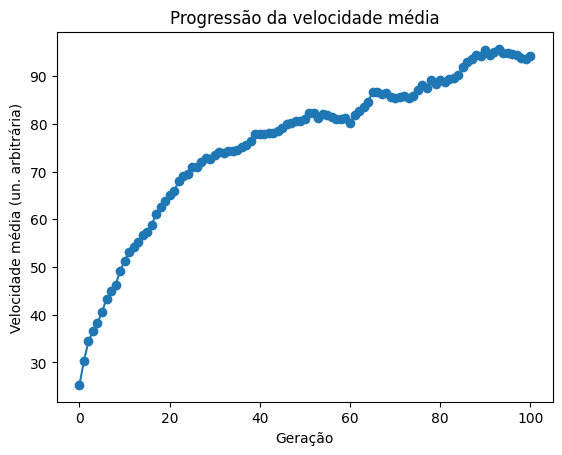

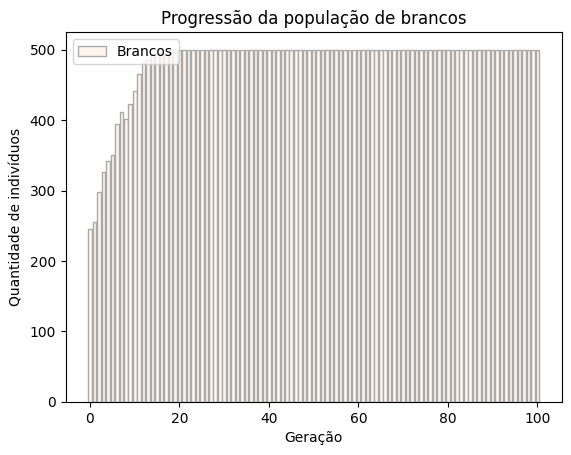

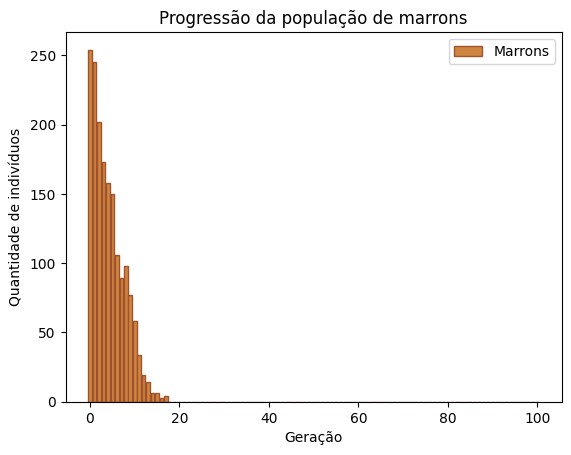

In [7]:
# Pede ao usuário o ambiente 

while True:

    print("Em qual ambiente você deseja simular a seleção natural: na floresta ou na neve?")
    ambiente = input().lower()
    
    if ambiente not in ["neve", "floresta"]:
        print ("Opa! Espere aí!! Ambiente fornecido inválido, tente novamente.")
        continue

    break

# Pede ao usuário o número de indivíduos

while True:
    
    print("Escreva o número de indivíduos para a simulação. O recomendado para uma população é maior que 100.")
    tamanho_populacao = input()

    if not tamanho_populacao.isdigit():
        print(f'Número fornecido inválido, tente usar apenas dígitos!!')
        continue

    tamanho_populacao = int(tamanho_populacao)
    if tamanho_populacao <= 1:
        print(f'Número fornecido inválido, tente usar apenas dígitos!!')
        continue
         
    break

# Chama todas as funções 

historico_brancos, historico_marrons, medias = simular(
    ambiente,
    tamanho_populacao
)

plotar_graficos(
    historico_brancos,
    historico_marrons,
    medias
)

## 5. Conclusão

##### Neste projeto, foi desenvolvida uma simulação computacional simplificada do processo de seleção natural utilizando a linguagem Python. A partir da construção de uma população inicial com características hereditárias, foi possível observar a dinâmica de sobrevivência, reprodução e variação ao longo de diferentes gerações, sob influência de diferentes condições ambientais. Conclui-se que o objetivo proposto — simular o processo de seleção natural e analisar suas consequências na composição de uma população — foi alcançado com sucesso. Os resultados obtidos mostraram-se coerentes com a teoria malthusiana e com os fundamentos da seleção natural. Além disso, a geração de gráficos permitiu uma visualização clara das mudanças populacionais, contribuindo para a compreensão dos efeitos das pressões ambientais no processo evolutivo. Como possíveis aprimoramentos futuros, destaca-se a inclusão de maior diversidade genética, interação entre indivíduos e fatores ecológicos mais complexos, como competição por recursos e deriva genética.

## 6. Referências

##### DARWIN, C. A origem das espécies. Londres: John Murray, 1859.

##### NÁPOLES, S. O crescimento exponencial de populações: Euler ou Malthus? Revista Ciência Elementar, v. 6, n. 2, p. 041, 2018. DOI: http://doi.org/10.24927/rce2018.041

##### MATPLOTLIB DEVELOPMENT TEAM. Matplotlib: Visualization with Python. Disponível em: https://matplotlib.org/

##### ‌OPENAI. ChatGPT [ferramenta de inteligência artificial]. Disponível em: https://chat.openai.com/.